# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [8]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [9]:
data =  Elias27

In [10]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 1000

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

### UV coverage Elias27

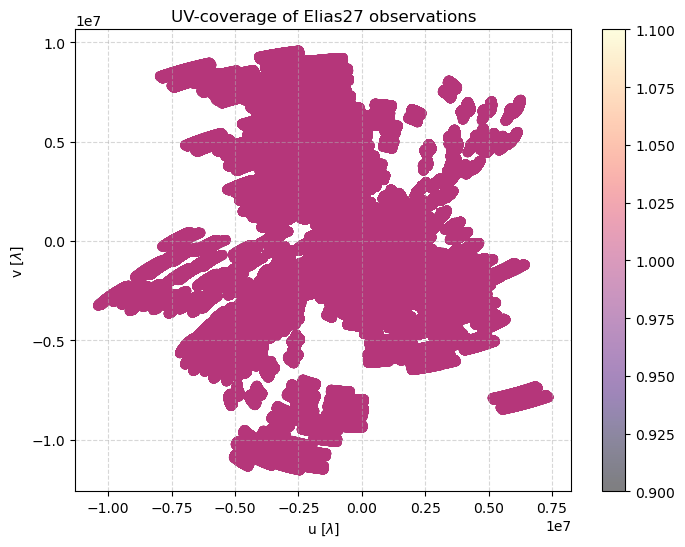

In [11]:
# plot 3D of the uv coverage

plt.figure(figsize=(8, 6))
scatter = plt.scatter(u, v, c= np.ones_like(Vis), cmap='magma', marker='o', alpha = 0.5)
plt.colorbar(scatter)

plt.xlabel(r'u [$\lambda$]')
plt.ylabel(r'v [$\lambda$]')
plt.title('UV-coverage of Elias27 observations')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



### Analitic functions

In [45]:
import numpy as np
from scipy.special import j0, j1, jn

In [46]:
def synthetic_uvtable_crescent(u, v,
                               sigma_core=0.04,
                               R_rings=[0.4, 0.6, 0.8],
                               width_rings=[0.05, 0.02, 0.05],
                               amp_core=0.1,
                               amp_rings=[0.05, 0.04, 0.03],
                               m_modes=[1, 0, 0],       # asymmetry order for each ring
                               theta0=[np.pi, 0, 0],   # phase angle of each asymmetry component
                               amp_asym=[0.5, 0.3, 0.3],  # relative strength of asymmetry
                               rad_to_arcsec=206265.0,
                               weights=None):
    """
    Generate a synthetic UV table using asymmetric Gaussian-width rings (Fourier-domain model).
    Asymmetries are introduced using low-order azimuthal modes (m-modes).
    """
    baseline = np.sqrt(u**2 + v**2)
    phi_uv = np.arctan2(v, u)  # uv-plane azimuth angle

    # Central Gaussian core (symmetric)
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)

    # Ring components with azimuthal modulation
    V_rings = np.zeros_like(baseline, dtype=complex)

    for A, R, w, m, th0, Aasym in zip(amp_rings, R_rings, width_rings, m_modes, theta0, amp_asym):
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)

        # Axisymmetric ring contribution (m = 0)
        V0 = A * j0(arg) * blur

        # Asymmetric contribution (m-mode modulation)
        Vm = Aasym * A * jn(m, arg) * blur * np.exp(1j * m * (phi_uv - th0))

        V_rings += V0 + Vm

    # Combine core + rings
    vis = V_core + V_rings

    # Default weights = uniform (if none provided)
    if weights is None:
        weights = np.ones_like(u)

    # Determine if noise should be real or complex
    dim0 = 2 if np.iscomplexobj(vis) else 1

    # Add Gaussian noise scaled by weights
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    # Return UV table dictionary
    uvtable = {
        'u': u,
        'v': v,
        'vis': vis,
        'weights': weights
    }

    return uvtable


In [118]:
def synthetic_uvtable_gaussian_blob(u, v,
                                    sigma_core=0.04,
                                    R_rings=[0.4, 0.6, 0.8],
                                    width_rings=[0.05, 0.02, 0.05],
                                    width_blobs=[0.03, 0.03, 0.03],
                                    amp_core=0.1,
                                    amp_rings=[0.05, 0.04, 0.03],
                                    m_modes=[1, 0, 0],
                                    theta0=[np.pi, 0, 0],
                                    amp_asym=[0.03, 0, 0],
                                    rad_to_arcsec=206265.0,
                                    weights=None):
    """
    Generate a synthetic UV table containing symmetric rings plus localized
    Gaussian 'blob' features.

    Asymmetries are introduced by adding a shifted 2D Gaussian component,
    modeled in the UV plane using the Fourier Shift Theorem.
    """
    baseline = np.sqrt(u**2 + v**2)
    
    # Central Gaussian core
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)

    # Rings + Gaussian blobs
    V_rings_and_blobs = np.zeros_like(baseline, dtype=complex)

    # Iterate through the properties of each ring/blob component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):

        # Symmetric ring component (m = 0)
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)
        V_ring = A * j0(arg) * blur

        V_rings_and_blobs += V_ring

        # Localized Gaussian blob (only if m != 0)
        if m != 0 and Aasym > 0:
            # Blob amplitude and width
            A_blob = Aasym * A
            R_blob = R
            sigma_blob = w_blob
            sigma_blob_rad = sigma_blob / rad_to_arcsec

            # Fourier transform of a centered Gaussian
            V_blob_centered = A_blob * np.exp(-2 * (np.pi * sigma_blob_rad * baseline)**2)

            # Blob center position in radians
            x0_rad = (R_blob / rad_to_arcsec) * np.cos(th0)
            y0_rad = (R_blob / rad_to_arcsec) * np.sin(th0)

            # Fourier shift: exp(-2π i (u·x0 + v·y0))
            phase_shift = np.exp(-2j * np.pi * (u * x0_rad + v * y0_rad))

            # Shifted blob visibility
            V_blob = V_blob_centered * phase_shift

            V_rings_and_blobs += V_blob

    # Total visibilities
    vis = V_core + V_rings_and_blobs
    vis = np.array(vis)

    # Default weights = uniform
    if weights is None:
        weights = np.ones_like(u)

    # Determine if noise should be real or complex
    dim0 = 2 if np.iscomplexobj(vis) else 1

    np.random.seed(93572)

    # Add Gaussian noise scaled by weights
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    print(noise)

    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    # Return UV table dict
    uvtable = {
        'u': u,
        'v': v,
        'vis': vis,
        'weights': weights
    }

    return uvtable


## Full UV-coverage

In [119]:
frank2d0 = Frank2D(N, rout, geom)

In [120]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [101]:
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
weights = frank2d0.gridded_data['weights']

In [102]:
uvtable_synthetic_full = synthetic_uvtable_gaussian_blob(u, v, weights= weights)

[[ inf -inf -inf ...  inf -inf  inf]
 [-inf -inf -inf ... -inf -inf  inf]]


In [103]:
vis_syn_full =  uvtable_synthetic_full['vis'].reshape(N, N)
weights_syn_full = uvtable_synthetic_full['weights'].reshape(N, N)
u_syn_full = uvtable_synthetic_full['u'].reshape(N, N)
v_syn_full = uvtable_synthetic_full['v'].reshape(N, N)


Text(0, 0.5, 'v [λ]')

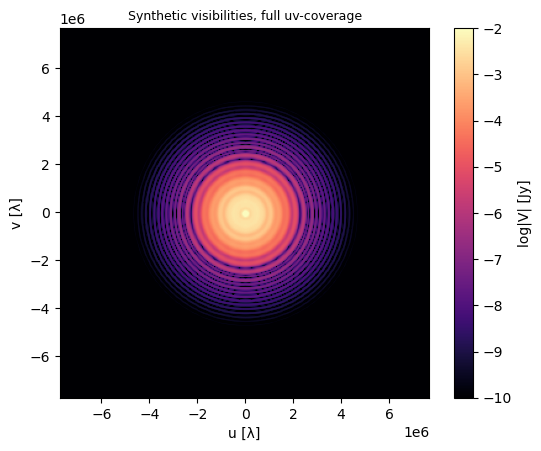

In [104]:
plt.imshow(np.log(np.abs(vis_syn_full)), 
            extent = [u_syn_full.min(), u_syn_full.max(), v_syn_full.min(), v_syn_full.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)

plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities, full uv-coverage', size=9)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

In [92]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
I_syn_full = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn_full))).real/(dx * dy)

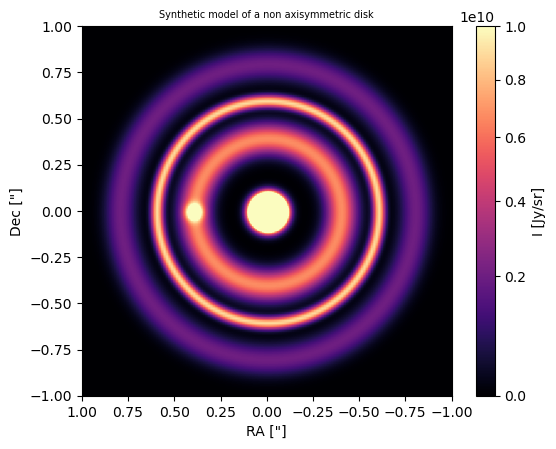

In [97]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 0.7, vmin = 0, vmax = 1e10)

plt.imshow(
            I_syn_full, 
            extent=[frank2d.Rmax, -frank2d.Rmax, -frank2d.Rmax, frank2d.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout/2, -rout/2)
plt.ylim(-rout/2, rout/2)
plt.title('Synthetic model of a non axisymmetric disk', size =7)
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')

## Elias27 UV-coverage

In [144]:
uvtable_synthetic = synthetic_uvtable_gaussian_blob(uvtable['u'], uvtable['v'], weights=uvtable['weights'])

[[ 0.01353533 -0.01008821  0.04930858 ...  0.04674869  0.02734788
  -0.05942386]
 [-0.02098779 -0.01096698 -0.02484401 ...  0.0110301  -0.02325816
  -0.02881985]]


In [145]:
u_syn, v_syn = uvtable_synthetic['u'], uvtable_synthetic['v']
vis_syn = uvtable_synthetic['vis']
weights_syn = uvtable_synthetic['weights']

In [130]:
#np.savez_compressed("uvtable_nonsym_disc_blob_noisy.npz", **uvtable_synthetic)

In [122]:
N = 300
rout = 1*2
frank2d = Frank2D(N, rout, geom)

In [123]:
frank2d.process_vis(uvtable_synthetic)

===>  Setting gridded data...


In [124]:
uvtable_synthetic_gridded = frank2d.gridded_data

In [125]:
u_syn = uvtable_synthetic_gridded['u'].reshape(N, N)
v_syn = uvtable_synthetic_gridded['v'].reshape(N, N)
vis_syn = uvtable_synthetic_gridded['vis'].reshape(N, N)
weights_syn = uvtable_synthetic_gridded['weights'].reshape(N, N)

In [ ]:
# CASA Script: Injects an analytical model into a Measurement Set
# Must be run inside CASA
#
# This version is corrected to handle MS files with
# varying numbers of channels per SPW.

import numpy as np
from taskinit import tbtool
from scipy.special import j0
import os
import sys

# -----------------------------------------------------------------
# 1. ANALYTICAL VISIBILITY FUNCTION (Unchanged)
# -----------------------------------------------------------------

def synthetic_uvtable_gaussian_blob(u, v,
                                    sigma_core=0.04,
                                    R_rings=[0.4, 0.6, 0.8],
                                    width_rings=[0.05, 0.02, 0.05],
                                    width_blobs=[0.03, 0.03, 0.03],
                                    amp_core=0.1,
                                    amp_rings=[0.05, 0.04, 0.03],
                                    m_modes=[1, 0, 0],
                                    theta0=[np.pi, 0, 0],
                                    amp_asym=[0.03, 0, 0],
                                    rad_to_arcsec=206265.0,
                                    weights=None):
    """
    Generate a synthetic UV table containing symmetric rings plus localized
    Gaussian 'blob' features.
    """
    baseline = np.sqrt(u**2 + v**2)
    
    # Central Gaussian core
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)

    # Rings + Gaussian blobs
    V_rings_and_blobs = np.zeros_like(baseline, dtype=complex)

    # Iterate through the properties of each ring/blob component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):

        # Symmetric ring component (m = 0)
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)
        V_ring = A * j0(arg) * blur

        V_rings_and_blobs += V_ring

        # Localized Gaussian blob (only if m != 0)
        if m != 0 and Aasym > 0:
            # Blob amplitude and width
            A_blob = Aasym * A
            R_blob = R
            sigma_blob = w_blob
            sigma_blob_rad = sigma_blob / rad_to_arcsec

            # Fourier transform of a centered Gaussian
            V_blob_centered = A_blob * np.exp(-2 * (np.pi * sigma_blob_rad * baseline)**2)

            # Blob center position in radians
            x0_rad = (R_blob / rad_to_arcsec) * np.cos(th0)
            y0_rad = (R_blob / rad_to_arcsec) * np.sin(th0)

            # Fourier shift: exp(-2*pi*j * (u*x0 + v*y0))
            phase_shift = np.exp(-2j * np.pi * (u * x0_rad + v * y0_rad))

            # Shifted blob visibility
            V_blob = V_blob_centered * phase_shift

            V_rings_and_blobs += V_blob

    # Total visibilities (Pure Model)
    vis = V_core + V_rings_and_blobs
    vis = np.array(vis)

    # --- Noise generation (not used for MODEL_DATA) ---
    if weights is None:
        weights = np.ones_like(u)
    dim0 = 2 if np.iscomplexobj(vis) else 1
    np.random.seed(93572)
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5
    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]
    # --- End of noise generation ---

    # Return UV table dict
    uvtable = {
        'u': u,
        'v': v,
        'vis': vis,  # Return the pure model visibilities
        'weights': weights
    }
    return uvtable

# -----------------------------------------------------------------
# 2. MAIN SCRIPT TO CREATE AND POPULATE THE MS (MODIFIED)
# -----------------------------------------------------------------
    
def create_ms():
    """
    Copies an existing MS and injects the synthetic model
    into its MODEL_DATA column, respecting the original flags.
    This version reads/writes row-by-row to handle varying SPWs.
    """
    
    # Speed of light in m/s
    clight = 2.99792458e+8  

    # --- Configuration ---
    ms_original = 'Elias27_continuum.ms' # Input MS (template)
    ms_for_model = 'Blob.ms'             # Output MS (will be created)
    # ---------------------

    # Check if the original MS exists
    if not os.path.exists(ms_original):
        print("Error: Original MS not found: " + str(ms_original))
        print("Please check the 'ms_original' variable.")
        return

    # Make a copy to avoid overwriting your original data
    if os.path.exists(ms_for_model):
        print("Deleting old copy: " + str(ms_for_model) + "...")
        os.system("rm -rf " + str(ms_for_model))

    print("Copying " + str(ms_original) + " to " + str(ms_for_model) + "...")
    os.system("cp -r " + str(ms_original) + " " + str(ms_for_model))

    # Initialize the CASA table tool
    tb = tbtool()

    print("Opening " + str(ms_for_model) + " to read structure...")
    try:
        # Open to read non-array columns first
        tb.open(ms_for_model) 
    except Exception as e:
        print("Error opening MS " + str(ms_for_model) + ": " + str(e))
        return

    # Read the MS structure
    # These columns are safe to read all at once
    uvw_coords = tb.getcol('UVW')           # Shape: [3, n_rows]
    ddid = tb.getcol('DATA_DESC_ID')        # Shape: [n_rows]
    
    # <-- MODIFIED: Get n_rows from tb.nrows()
    n_rows = tb.nrows()

    # <-- MODIFIED: We CANNOT read FLAG or get global shape here
    # flag_col = tb.getcol('FLAG')          # <-- REMOVED (This was the error)
    # data_shape = flag_col.shape           # <-- REMOVED
    # n_pol, n_chan, n_rows = data_shape    # <-- REMOVED

    print("MS has: " + str(n_rows) + " total rows.")
    tb.close()

    # Read frequencies (from the sub-table)
    try:
        tb.open(ms_for_model + '/SPECTRAL_WINDOW')
        freqs_per_spw = tb.getcol('CHAN_FREQ') # List of arrays [n_spw][n_chan]
        tb.close()
        print("Structure and frequencies read successfully.")
    except Exception as e:
        print("Error reading SPECTRAL_WINDOW table: " + str(e))
        return

    # <-- MODIFIED: We cannot create a single giant array for the model
    # new_model_data = np.zeros(data_shape, dtype=np.complex64) # <-- REMOVED

    print("Starting model calculation per row...")
    
    # <-- NEW: Re-open the table in write mode
    try:
        tb.open(ms_for_model, nomodify=False)
    except Exception as e:
        print("Error opening MS for writing: " + str(e))
        return

    # Iterate over EACH row of the .ms
    for i in range(n_rows):
        if i % 50000 == 0: # Print progress
            print("Processing row " + str(i) + " of " + str(n_rows) + "...")
            
        # A. Get (u,v) coordinates in meters
        u_m = uvw_coords[0, i]
        v_m = uvw_coords[1, i]
        
        # B. Get frequencies (in Hz) for this row
        spw_index = ddid[i]
        row_freqs_hz = freqs_per_spw[spw_index] # Array of shape [n_chan_this_row]
        
        # <-- NEW: Read FLAG for THIS ROW ONLY
        # np.squeeze removes the 3rd dimension (of 1)
        row_flags = np.squeeze(tb.getcol('FLAG', startrow=i, nrow=1))
        
        # <-- NEW: Get n_pol and n_chan from this row's shape
        if row_flags.ndim == 1:
            # Handle case of 1 polarization
            n_pol = 1
            n_chan = row_flags.shape[0]
            row_flags = row_flags.reshape((1, n_chan)) # Ensure 2D shape
        else:
            n_pol, n_chan = row_flags.shape

        # --- Sanity check ---
        # Ensure freq array and flag array have same number of channels
        if len(row_freqs_hz) != n_chan:
            print("Warning: Channel mismatch in row " + str(i) + "!")
            print("  SPW_TABLE has " + str(len(row_freqs_hz)) + " chans.")
            print("  FLAG_COL has " + str(n_chan) + " chans.")
            print("  Skipping this row.")
            continue
        # --- End sanity check ---
        
        # C. Calculate (u,v) in lambdas FOR EACH CHANNEL
        u_lambda_chans = u_m * row_freqs_hz / clight
        v_lambda_chans = v_m * row_freqs_hz / clight
        
        # D. (row_flags is already defined)
        
        # E. Create a mask for unflagged channels
        if n_pol == 1:
            mask_not_flagged = np.logical_not(row_flags[0, :])
        elif n_pol == 2: # Assuming XX, YY
            mask_not_flagged = np.logical_not(row_flags[0, :]) * np.logical_not(row_flags[1, :])
        elif n_pol == 4: # Assuming XX, XY, YX, YY
            mask_not_flagged = np.logical_not(row_flags[0, :]) * np.logical_not(row_flags[3, :])
        else:
            mask_not_flagged = np.logical_not(row_flags[0, :]) # Fallback

        # Get the indices of the valid (unflagged) channels
        valid_indices = np.where(mask_not_flagged)[0]
        
        # If all channels in this row are flagged, skip
        if len(valid_indices) == 0:
            continue
            
        # F. FILTER (u,v) COORDINATES
        u_lambda_valid = u_lambda_chans[valid_indices]
        v_lambda_valid = v_lambda_chans[valid_indices]
        
        # G. CALL THE ANALYTICAL FUNCTION
        uvtable_dict = synthetic_uvtable_gaussian_blob(u_lambda_valid, v_lambda_valid)
        
        # Extract the pure model from the dictionary
        simulated_vis = uvtable_dict['vis'] # Array of shape [len(valid_indices)]
        
        # <-- NEW: Create a model array for THIS ROW
        row_model_data = np.zeros((n_pol, n_chan), dtype=np.complex64)
        
        # H. POPULATE THE ROW'S MODEL ARRAY
        for pol in range(n_pol):
            row_model_data[pol, valid_indices] = simulated_vis

        # <-- NEW: Write this row's model data back to the MS
        # We must reshape it back to [n_pol, n_chan, 1] for writing
        row_model_data_to_write = row_model_data.reshape((n_pol, n_chan, 1))
        tb.putcol('MODEL_DATA', row_model_data_to_write, startrow=i, nrow=1)

    print("Model calculation finished.")
    
    # <-- NEW: Close the table
    tb.close()
    print("MODEL_DATA column updated successfully.")
    print("You can now run tclean on " + str(ms_for_model) + " with datacolumn='model'")

    # <-- MODIFIED: Removed the old writing block
    # 3. ESCRITURA EN EL .MS ...

# -----------------------------------------------------------------
# 4. EXECUTION
# -----------------------------------------------------------------

# This makes the script runnable directly in CASA
if __name__ == "__main__":
    
    # Check if tbtool is available (i.e., if we are in CASA)
    try:
        tb = tbtool()
        del tb
    except NameError:
        print("Error: This script must be run inside CASA.")
        print("Start CASA and then run:")
        print("execfile('your_script_name.py')")
        sys.exit(1)

    print("--- Starting MS Model Injection Script ---")
    create_ms()
    print("--- Script finished ---")

Text(0, 0.5, 'v [λ]')

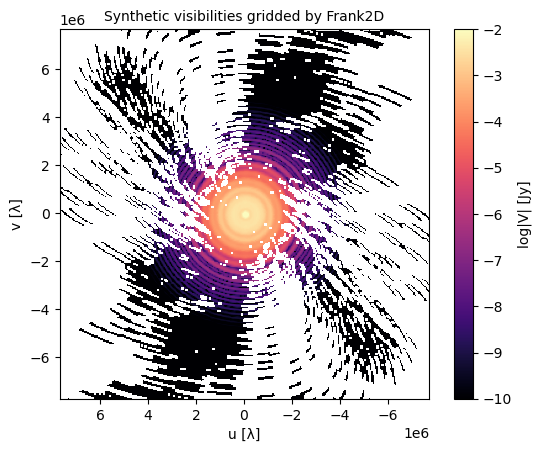

In [126]:
plt.imshow(np.log(np.abs(vis_syn)),
             extent=[u_syn.max(), u_syn.min(), v_syn.min(), v_syn.max()],
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities gridded by Frank2D', size=10)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

In [132]:
params_1 = {'m' : -2, 'c' : 1e8, 'l' : 7e4}
params_2 = {'m' : -1.8, 'c' : 1e9, 'l' : 7e4}
params_3 = {'m' : -1.5, 'c' : 1e9, 'l' : 7e4}
best = {'m': -2.0109174914721892, 'c': 10930405059.44571, 'l': 2633846.3020098973}

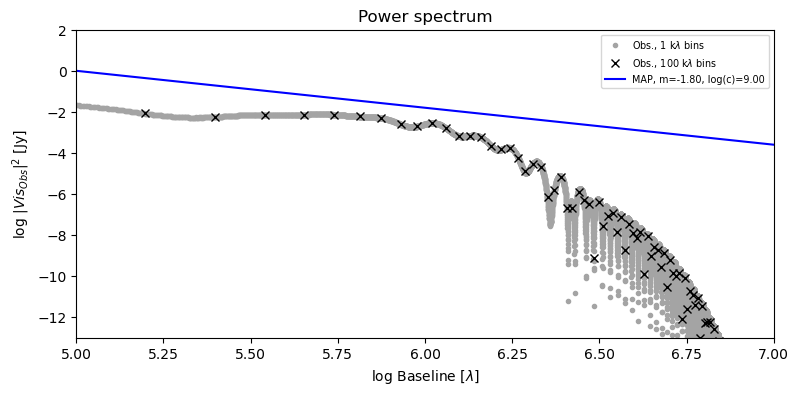

In [146]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u_syn.flatten(), v_syn.flatten()
Vis = vis_syn.flatten()
Weights = weights_syn.flatten()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy1 = linear_power_spectrum(lgx, params_1['m'], params_1['c'])
lgy2 = linear_power_spectrum(lgx, params_2['m'], params_2['c'])
lgy3 = linear_power_spectrum(lgx, params_3['m'], params_3['c'])
#lgy_best = linear_power_spectrum(lgx, best['m'], best['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(lgx, lgy1, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_1['m'], np.log10(params_1['c'])))
plt.plot(lgx, lgy2, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_2['m'], np.log10(params_2['c'])))
#plt.plot(lgx, lgy3, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_3['m'], np.log10(params_3['c'])))
#plt.plot(lgx, lgy_best, ls='--', color= 'orange', label='Best fit, m={:.2f}, log(c)={:.2f}'.format(best['m'], np.log10(best['c'])))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-13, 2)
plt.xlim(5, 7)
plt.show()

In [133]:
dx = frank2d.dx/rad_to_arcsec
dy = frank2d.dy/rad_to_arcsec
I_syn = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn))).real/(dx * dy)

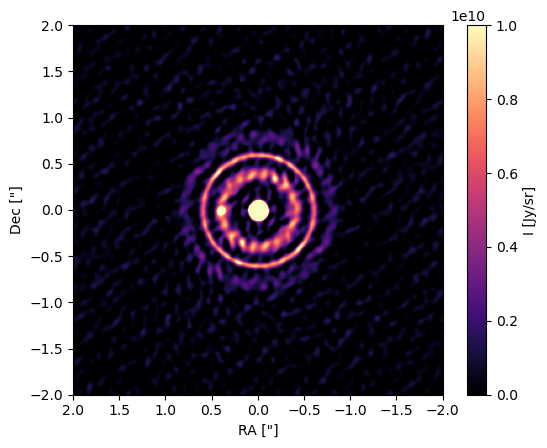

In [134]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmin = 0, vmax = 1e10)

plt.imshow(
            I_syn, 
            extent=[frank2d.Rmax, -frank2d.Rmax, -frank2d.Rmax, frank2d.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Synthetic model of a non axisymmetric disk')
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')

### dummy frank2d

In [135]:
geom = Geometry(0, 0, 0, 0)

In [136]:
N = 300
rout = 1*2

In [137]:
frank2d2 = Frank2D(N, rout, geom)

===>  Setting gridded data...
===>  Setting GP Kernel Wendland...
        + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 70000.0}
===>  Creating sparse linear system...
        + time kernel = 0.03  min |  2.01 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.03  min |  2.07 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.012212677737961322
                       .... iteration:  0
                             -> actual tol  1.22e+08  versus  1.22e-02
                       .... iteration:  1
                             -> actual tol  1.05e+07  versus  1.22e-02
                       .... iteration:  2
                             -> actual tol  9.43e+06  versus  1.22e-02
                       .... iteration:  3
                             -> actual tol  1.47e+07  versus  1.22e-02
                       .... iteration:  4
                             -> actual tol  3.

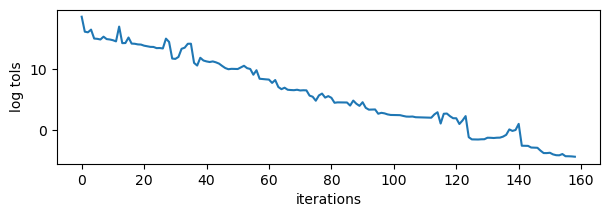

         + time BiCGStab = 0.07  min |  4.45 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.06  min |  3.36 seconds


In [138]:
frank2d2.fit(data = uvtable_synthetic, kernel_params = params_1, rtol = 1e-10)

In [139]:
Plot_ = Plot(frank2d2)

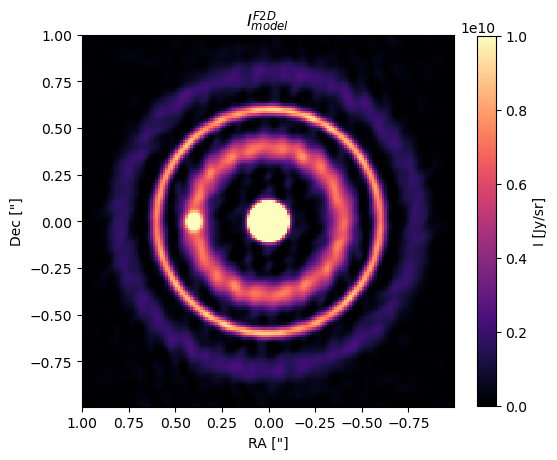

In [143]:
Plot_.intensity(vmax=1e10, gamma = 1, zoom = 2, title = r'$I_{model}^{F2D}$')

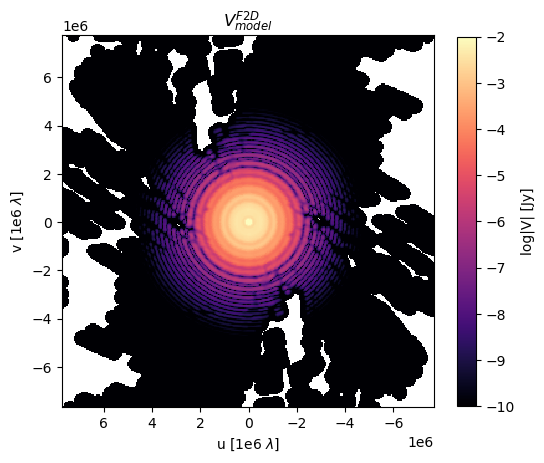

In [141]:
Plot_.visibility(fig_size=6, title= r'$V_{model}^{F2D}$')

###  Best

In [46]:
initial_guess = {'m': -2, 'logl': 4}

In [47]:
frank2d2.search_MAP(initial_guess= initial_guess, N = 50) #31m5.5s

Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...
  + Time to set up the matrices: 128.28 seconds
Setting the initial guess...
Optimizing the posterior...


In [51]:
frank2d2.MAP

{'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}

In [49]:
best_blob_N60 = {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 57461.09572521277}

In [52]:
best_blob_N50 = {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}


### frank2d with best values

In [76]:
N3 = 500

In [77]:
frank2d3 = Frank2D(N3, rout, geom)

===>  Creating sparse linear system...


    + time kernel = 0.04  min |  2.13 seconds
Using preconditioner method:  jacobi
    + time building system = 0.04  min |  2.19 seconds
===>  Solving linear system...
     + maxiter =  50000  & rtol =  1e-11
         * rtol: 1e-11
         * final tolerance: 0.0012212677737961325
     + final tolerance :  0.0012212677737961325
                       .... iteration:  0
                        -> actual tol:  122126777.37961327  vs  0.0012212677737961325
                       .... iteration:  1
                        -> actual tol:  9671377.288413243  vs  0.0012212677737961325
                       .... iteration:  2
                        -> actual tol:  9756413.172949875  vs  0.0012212677737961325
                       .... iteration:  3
                        -> actual tol:  51158635.02872883  vs  0.0012212677737961325
                       .... iteration:  4
                        -> actual tol:  3075114.607068556  vs  0.0012212677737961325
                       .... itera

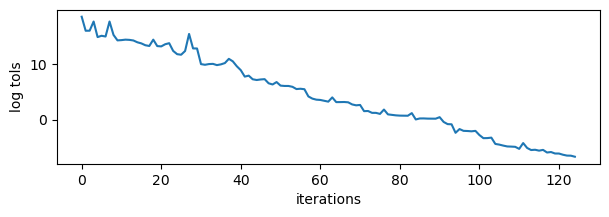

    + time = 0.05  min |  3.03 seconds
     + CGM converged?   True
         ✔✔✔✔✔✔✔ CGM Sucess..
     + Fit correctly?   None
Building full visibility model...
--> times building full visibility model = 0.10  min |  6.18 seconds


In [80]:
frank2d3.fit(data = uvtable_synthetic, kernel_params = best_blob_2, rtol = 1e-8) # 1m7s

In [81]:
Plot_3 = Plot(frank2d3)

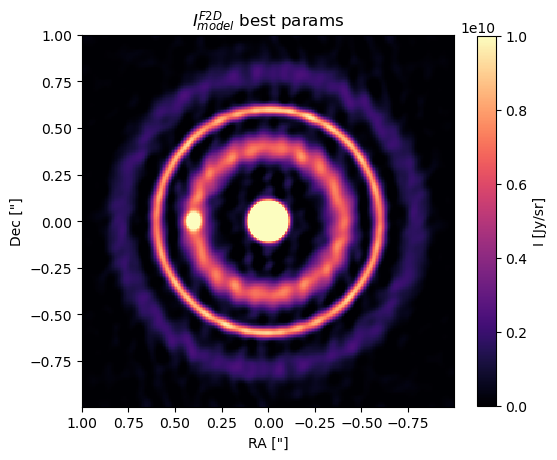

In [82]:
Plot_3.intensity(vmax=1e10,  gamma = 1, zoom=2, title = r'$I_{model}^{F2D}$ best params')

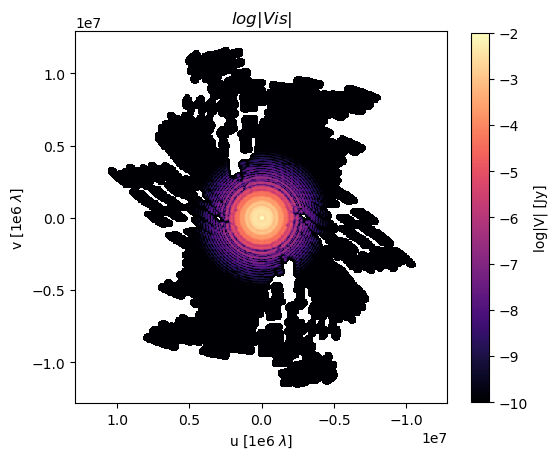

In [83]:
Plot_3.visibility(fig_size=6)